Polynomial Training MSE: 1.5146129380243427e-28
Polynomial Testing MSE: 11.111111111111091


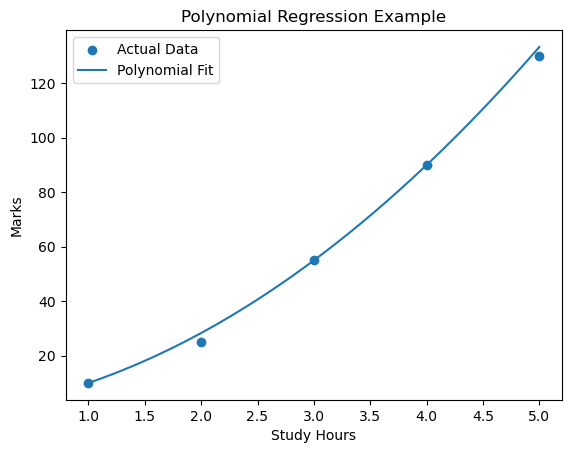

Linear Training MSE: 14.8809523809524
Linear Testing MSE: 196.23724489795967


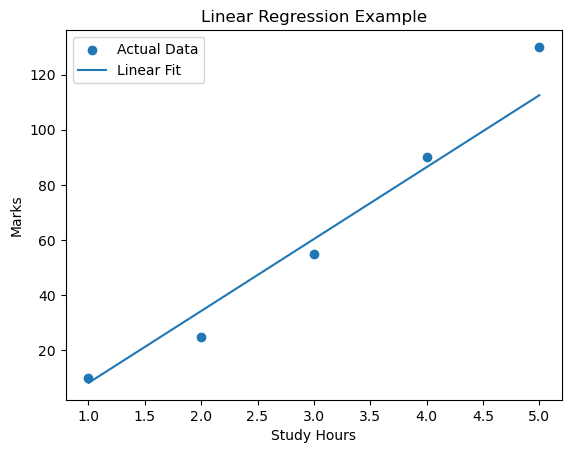

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

data = {
    'Study_Hours':[1,2,3,4,5],
    'Marks':[10,25,55,90,130]
}

df = pd.DataFrame(data)

X = df[['Study_Hours']]
y = df['Marks']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly, y_train)

y_train_pred = model.predict(X_train_poly)
y_test_pred = model.predict(X_test_poly)

print("Polynomial Training MSE:", mean_squared_error(y_train, y_train_pred))
print("Polynomial Testing MSE:", mean_squared_error(y_test, y_test_pred))

plt.scatter(X, y, label='Actual Data')
X_line = pd.DataFrame({'Study_Hours': np.linspace(X['Study_Hours'].min(), X['Study_Hours'].max(), 100)})
y_line = model.predict(poly.transform(X_line))
plt.plot(X_line, y_line, label='Polynomial Fit')
plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.title('Polynomial Regression Example')
plt.legend()
plt.show()

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

print("Linear Training MSE:", mean_squared_error(y_train, y_train_pred))
print("Linear Testing MSE:", mean_squared_error(y_test, y_test_pred))

plt.scatter(X, y, label='Actual Data')
plt.plot(X, linear_model.predict(X), label='Linear Fit')
plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.title('Linear Regression Example')
plt.legend()
plt.show()